<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/Combined_Spat_Oxygen_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Loading & Standardization (Respiration)
This block pulls the oxygen consumption rates from all four files, cleans the morph labels (HF vs NF), and maps the experimental treatments.

In [31]:
import pandas as pd
import numpy as np

# --- HELPER FUNCTION ---
def clean_morph(val):
    val = str(val).strip().upper()
    if 'HF' in val or 'HIGH' in val: return 'HF'
    if 'NF' in val or 'NO' in val: return 'NF'
    return None

# 1. Load Files
df_amb = pd.read_csv('ambient.csv')
df_ph = pd.read_csv('pH_Assay.csv')
df_temp = pd.read_csv('Temp_Assay.csv')
df_light = pd.read_csv('Light_Assay.csv')

# 2. Map Treatments and Clean Morphs
# Ambient
df_amb['morph'] = df_amb['color'].apply(clean_morph)
df_amb['Treatment'] = 'Ambient \n(23°C, pH 8.2, 10m)'

# pH (Keep only stress levels)
df_ph['morph'] = df_ph['color'].apply(clean_morph)
df_ph = df_ph[df_ph['pH'].isin([7.6, 7.8])].copy()
df_ph['Treatment'] = df_ph['pH'].apply(lambda x: f"pH {x}")

# Temp (Keep only stress levels)
df_temp['morph'] = df_temp['color'].apply(clean_morph)
df_temp = df_temp[df_temp['temp'].isin([27, 32])].copy()
df_temp['Treatment'] = df_temp['temp'].apply(lambda x: f"{x}°C")

# Light (Keep only 50m and Dark)
df_light['morph'] = df_light['color'].apply(clean_morph)
df_light = df_light[df_light['LightDepth'].str.lower().isin(['50m', 'dark'])].copy()
df_light['Treatment'] = df_light['LightDepth'].str.capitalize()

# 3. Combine into Master Respiration DataFrame
cols = ['SampleCode', 'morph', 'OxyRate nmol/mm2/min', 'Treatment']
master_respiration = pd.concat([df_amb[cols], df_ph[cols], df_temp[cols], df_light[cols]])

# Drop PF and missing values
master_respiration = master_respiration[master_respiration['morph'].isin(['HF', 'NF'])].dropna()
master_respiration = master_respiration.rename(columns={'OxyRate nmol/mm2/min': 'oxy_rate'})

print("Block 1 Complete: Master Respiration Data Merged.")

Block 1 Complete: Master Respiration Data Merged.


# Block 2: Outlier Removal & "Removed Samples" List

This block will not only clean the data using the $1.5 \times \text{IQR}$ rule but will also print the specific IDs and treatments of the samples that were removed.

In [32]:
# ==========================================
# BLOCK 2: OUTLIER REMOVAL & LOGGING
# ==========================================

 # Removing negetive results
respiration_clean = respiration_clean[respiration_clean['oxy_rate'] >= 0].copy()
print(f"Removed negative respiration rates. Final N for analysis: {len(respiration_clean)}")
negative_removed_respiration = removed_respiration[removed_respiration['oxy_rate'] < 0]

print("--- SAMPLES REMOVED (NEGATIVE RESPIRATION RATES) ---")
if negative_removed_respiration.empty:
    print("No negative respiration rates were found among the removed samples.")
else:
    print(negative_removed_respiration.to_string(index=False))


master_respiration['is_outlier'] = False

for names, group in master_respiration.groupby(['morph', 'Treatment']):
    q1 = group['oxy_rate'].quantile(0.25)
    q3 = group['oxy_rate'].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    # Identify indices of outliers for this group
    indices = group[(group['oxy_rate'] < lower) | (group['oxy_rate'] > upper)].index
    master_respiration.loc[indices, 'is_outlier'] = True

# 1. Generate the list of samples that got removed
removed_respiration = master_respiration[master_respiration['is_outlier'] == True][['SampleCode', 'morph', 'Treatment', 'oxy_rate']]

print("\n--- SAMPLES REMOVED (RESPIRATION OUTLIERS) ---")
if removed_respiration.empty:
    print("No outliers detected in this dataset.")
else:
    print(removed_respiration.to_string(index=False))

# 2. Create the clean dataset for analysis
respiration_clean = master_respiration[master_respiration['is_outlier'] == False].copy()

print(f"\nBlock 2 Complete. {len(removed_respiration)} outliers removed.")
print(f"Final N for analysis: {len(respiration_clean)}")

Removed negative respiration rates. Final N for analysis: 246
--- SAMPLES REMOVED (NEGATIVE RESPIRATION RATES) ---
     SampleCode morph                     Treatment  oxy_rate
plateB_NF_27C_8    NF Ambient \n(23°C, pH 8.2, 10m)   -0.0894
     plate3_24c    NF                          32°C   -0.0443

--- SAMPLES REMOVED (RESPIRATION OUTLIERS) ---
         SampleCode morph                     Treatment  oxy_rate
    plateD_NF_8.2_7    NF Ambient \n(23°C, pH 8.2, 10m)  4.214200
plateE_HF_control_2    HF Ambient \n(23°C, pH 8.2, 10m)  0.100200
plateE_HF_control_2    HF Ambient \n(23°C, pH 8.2, 10m)  0.125200
    plateA_HF_27C_8    HF Ambient \n(23°C, pH 8.2, 10m)  0.545900
    plateB_NF_27C_8    NF Ambient \n(23°C, pH 8.2, 10m) -0.089400
plateF_NF_control_5    HF Ambient \n(23°C, pH 8.2, 10m)  0.244700
plateF_NF_control_7    NF Ambient \n(23°C, pH 8.2, 10m)  0.234900
plateE_HF_control_5    HF Ambient \n(23°C, pH 8.2, 10m)  0.358700
    plateD_NF_8.2_3    NF Ambient \n(23°C, pH 8.2, 10m)  

# Block 3: Normality Check (Shapiro-Wilk Test)
This block tests whether each phenotypic cohort (HF vs. NF) in every environmental condition follows a normal distribution. Because respiration rates can be highly sensitive to stress, we often see skewed distributions here, making this check critical for scientific validity.

In [33]:
from scipy import stats

# ==========================================
# BLOCK 3: NORMALITY CHECK (RESPIRATION)
# ==========================================

print("--- BLOCK 3: RUNNING NORMALITY CHECKS ---")

oxy_normality_results = []

# Group by Treatment and Morph to check each cohort independently
for (treat, morph), group in respiration_clean.groupby(['Treatment', 'morph']):
    data = group['oxy_rate']

    # Shapiro-Wilk requires a minimum of 3 samples
    if len(data) >= 3:
        shapiro_stat, p_value = stats.shapiro(data)
        is_normal = p_value > 0.05  # Standard alpha threshold
    else:
        # Cannot reliably test normality for tiny N
        shapiro_stat, p_value = np.nan
        is_normal = False

    oxy_normality_results.append({
        'Treatment': treat,
        'Morph': morph,
        'N': len(data),
        'W_Statistic': round(shapiro_stat, 4) if not np.isnan(shapiro_stat) else np.nan,
        'p_value': round(p_value, 4) if not np.isnan(p_value) else np.nan,
        'Normal_Distribution': is_normal
    })

# Create the Normality DataFrame for reporting
oxy_normality_df = pd.DataFrame(oxy_normality_results)

# Display the report
print("\n[RESPIRATION NORMALITY REPORT]")
print(oxy_normality_df.to_string(index=False))

# Calculate status
failed_oxy_groups = oxy_normality_df[oxy_normality_df['Normal_Distribution'] == False]

if failed_oxy_groups.empty:
    print("\nCONCLUSION: All respiration groups are normally distributed.")
    print("ACTION: Use PARAMETRIC tests (T-test/ANOVA).")
else:
    print(f"\nCONCLUSION: {len(failed_oxy_groups)} groups failed the normality test.")
    print("ACTION: The pipeline will automatically switch to NON-PARAMETRIC tests (Mann-Whitney U) for these stressors.")

--- BLOCK 3: RUNNING NORMALITY CHECKS ---

[RESPIRATION NORMALITY REPORT]
                    Treatment Morph  N  W_Statistic  p_value  Normal_Distribution
                         27°C    HF 25       0.8980   0.0166                False
                         27°C    NF 28       0.8867   0.0057                False
                         32°C    HF  9       0.8799   0.1568                 True
                         32°C    NF  7       0.9187   0.4595                 True
                          50m    HF 19       0.9347   0.2116                 True
                          50m    NF 11       0.8584   0.0550                 True
Ambient \n(23°C, pH 8.2, 10m)    HF 76       0.9514   0.0055                False
Ambient \n(23°C, pH 8.2, 10m)    NF 48       0.8638   0.0001                False
                         Dark    HF 10       0.8957   0.1965                 True
                         Dark    NF  6       0.8974   0.3587                 True
                       p

# Block 4: Automated Statistical Analysis (Respiration).
This block performs the direct metabolic comparison between High-Fluorescent (HF) and Non-Fluorescent (NF) recruits. By using the distribution data from Block 3, it ensures that your $p$-values are calculated using the most conservative and accurate mathematical approach.

In [34]:
# ==========================================
# BLOCK 4: AUTOMATED STATISTICAL ANALYSIS
# ==========================================

print("--- BLOCK 4: PERFORMING COMPARATIVE METABOLIC STATS ---")

oxy_stats_results = []

# Analyze each Treatment condition separately
for treat in respiration_clean['Treatment'].unique():
    # Subset data for this specific condition
    subset = respiration_clean[respiration_clean['Treatment'] == treat]
    hf_data = subset[subset['morph'] == 'HF']['oxy_rate']
    nf_data = subset[subset['morph'] == 'NF']['oxy_rate']

    # 1. Automatic Test Selection
    # Check if BOTH morphs in this treatment are normal
    subset_normality = oxy_normality_df[oxy_normality_df['Treatment'] == treat]
    is_normal = subset_normality['Normal_Distribution'].all()

    # Run comparison (requires at least 2 samples per group)
    if len(hf_data) >= 2 and len(nf_data) >= 2:
        if is_normal:
            # PARAMETRIC: Independent T-test
            stat, p_val = stats.ttest_ind(hf_data, nf_data)
            test_name = "Independent T-test"
        else:
            # NON-PARAMETRIC: Mann-Whitney U test
            stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
            test_name = "Mann-Whitney U"
    else:
        p_val, test_name = np.nan, "Insufficient N"

    # 2. Record Results
    oxy_stats_results.append({
        'Condition': treat,
        'HF_Mean_Rate': round(hf_data.mean(), 4),
        'NF_Mean_Rate': round(nf_data.mean(), 4),
        'Diff (HF-NF)': round(hf_data.mean() - nf_data.mean(), 4),
        'p_value': round(p_val, 4) if not np.isnan(p_val) else np.nan,
        'Test_Used': test_name,
        'Significant': p_val < 0.05 if not np.isnan(p_val) else False
    })

# Convert to DataFrame for a clean summary table
oxy_results_df = pd.DataFrame(oxy_stats_results)

# Display the Final Summary
print("\n[RESPIRATION COMPARATIVE ANALYSIS SUMMARY]")
print(oxy_results_df[['Condition', 'HF_Mean_Rate', 'NF_Mean_Rate', 'p_value', 'Significant', 'Test_Used']].to_string(index=False))

# Export for your paper's supplemental data
oxy_results_df.to_csv("Respiration_Statistical_Results.csv", index=False)

--- BLOCK 4: PERFORMING COMPARATIVE METABOLIC STATS ---

[RESPIRATION COMPARATIVE ANALYSIS SUMMARY]
                    Condition  HF_Mean_Rate  NF_Mean_Rate  p_value  Significant          Test_Used
Ambient \n(23°C, pH 8.2, 10m)        0.6445        0.4137   0.0071         True     Mann-Whitney U
                       pH 7.6        1.1318        0.9871   0.6361        False Independent T-test
                       pH 7.8        0.4966        0.9025   0.0073         True Independent T-test
                         32°C        0.1927        0.0467   0.0283         True Independent T-test
                         27°C        0.2482        0.1917   0.2432        False     Mann-Whitney U
                          50m        0.5455        0.2551   0.0719        False Independent T-test
                         Dark        0.4786        0.3599   0.4817        False Independent T-test


In [38]:
significant_results = oxy_results_df[oxy_results_df['Significant'] == True]

print("\n--- STATISTICALLY SIGNIFICANT RESPIRATION RESULTS ---")
if significant_results.empty:
    print("No statistically significant differences were found.")
else:
    print(significant_results[['Condition', 'HF_Mean_Rate', 'NF_Mean_Rate', 'p_value', 'Test_Used']].to_string(index=False))


--- STATISTICALLY SIGNIFICANT RESPIRATION RESULTS ---
                    Condition  HF_Mean_Rate  NF_Mean_Rate  p_value          Test_Used
Ambient \n(23°C, pH 8.2, 10m)        0.6445        0.4137   0.0071     Mann-Whitney U
                       pH 7.8        0.4966        0.9025   0.0073 Independent T-test
                         32°C        0.1927        0.0467   0.0283 Independent T-test


# Block 5: High-Impact Visualization (Respiration-Only).
This plot is designed to be the "physiological heart" of your poster. It visualizes the metabolic cost of living for each phenotype across the environmental gradient. By showing the raw data points over the boxplots, you provide full transparency regarding the variance in your micro-respirometry measurements.

--- BLOCK 5 COMPLETE ---
Figure saved as 'Master_Respiration_Poster_Plot.png'.


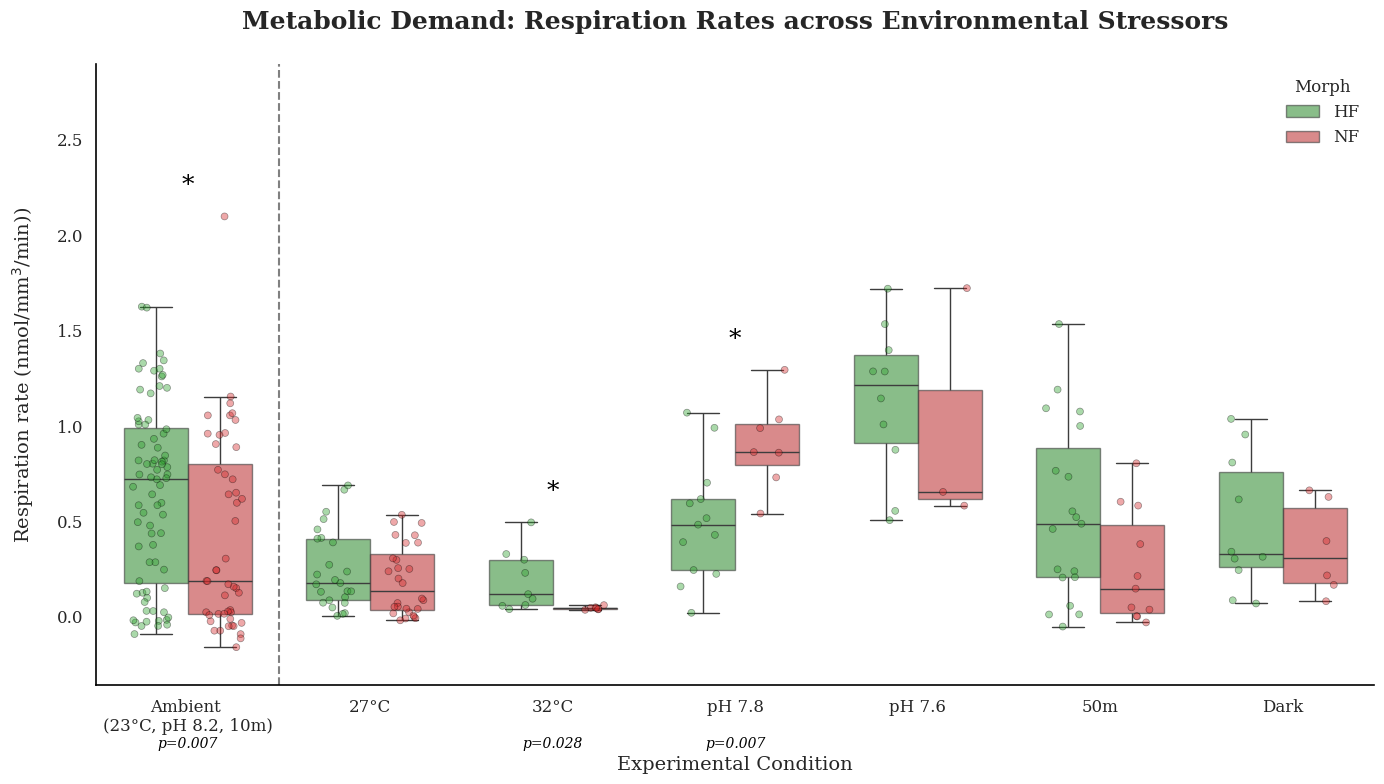

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# BLOCK 5: MASTER RESPIRATION PLOT
# ==========================================

# 1. Setup Aesthetics for Professional Poster
sns.set_theme(style="white")
plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

# Define phenotypic colors: Green for HF, Red/Coral for NF
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
# Logical progression from Ambient to Stressors
order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

fig, ax = plt.subplots(figsize=(14, 8))

# 2. Draw Boxplots (Medians and IQRs)
sns.boxplot(
    data=respiration_clean,
    x='Treatment',
    y='oxy_rate',
    hue='morph',
    order=order,
    palette=variant_colors,
    ax=ax,
    width=0.7,
    boxprops=dict(alpha=0.6),
    showfliers=False,
)

# 3. Overlay Raw Data (Jittered dots to show variance)
sns.stripplot(
    data=respiration_clean,
    x='Treatment',
    y='oxy_rate',
    hue='morph',
    order=order,
    palette=variant_colors,
    ax=ax,
    dodge=True,
    size=5,
    alpha=0.4,
    jitter=0.2,
    edgecolor='black',
    linewidth=0.5,
)

# 4. Labels and Formatting
ax.set_title(
    "Metabolic Demand: Respiration Rates across Environmental Stressors",
    fontsize=18,
    fontweight='bold',
    pad=25,
)
ax.set_xlabel("Experimental Condition", fontsize=14, labelpad=15)
ax.set_ylabel(
    r"Respiration rate (nmol/mm$^3$/min))",
    fontsize=14,
    labelpad=15,
)

# Add a vertical line after the Ambient group to visually separate it
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)

# Standardize the Y-axis range and add more space for p-values below
ax.set_ylim(respiration_clean['oxy_rate'].min() - 0.2, respiration_clean['oxy_rate'].max() + 0.8)

# Add asterisks and p-values for significant conditions
significant_results = oxy_results_df[oxy_results_df['Significant'] == True]
if not significant_results.empty:
    for idx, row in significant_results.iterrows():
        condition = row['Condition']
        p_value = row['p_value']
        if condition in order:
            x_pos = order.index(condition)  # Get the x-position of the treatment group

            # Calculate y-position for asterisk (slightly above max data point for this group)
            max_y = respiration_clean[(respiration_clean['Treatment'] == condition)]['oxy_rate'].max()
            text_y_asterisk = max_y + 0.1  # Adjust as needed for spacing
            text_y_pvalue = -0.7  # Place p-value further below the x-axis

            # Place asterisk centered above the two morphs for the significant condition
            # The 0.0 value for x-offset places it in the middle of the dodged boxplots.
            ax.text(x_pos, text_y_asterisk, '*', ha='center', va='bottom', fontsize=18, color='black')
            ax.text(
                x_pos,
                text_y_pvalue,
                f'p={p_value:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black',
                fontstyle='italic'
            )


# Clean up Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:2],
    ["HF", "NF"],
    title="Morph",
    loc='upper right',
    frameon=False,
    fontsize=12,
)

sns.despine()
plt.tight_layout()

plt.savefig("Master_Respiration_Poster_Plot.png", dpi=600, bbox_inches='tight')
plt.savefig("Master_Respiration_Poster_Plot.svg", dpi=600, bbox_inches='tight')
plt.savefig("Master_Respiration_Poster_Plot.pdf", dpi=600, bbox_inches='tight')

print("--- BLOCK 5 COMPLETE ---")
print("Figure saved as 'Master_Respiration_Poster_Plot.png'.")